<a href="https://colab.research.google.com/github/Mohamad-Selawy/Python/blob/master/Data%20Analysis/Level%202/outlier_detection_%26_distributions.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Outlier Detection & Data Distribution

As a data analyst, you don't just calculate numbers; you interpret them. Understanding how data is spread out (distribution) and identifying 'weird' data points (outliers) are two critical steps before you can build any reliable business report.

----

## Learning Objectives

By the end of this notebook, you should be able to:

*   Understand what outliers are.
*   Understand data distributions.
*   Interpret histograms and boxplots.
*   Understand skewness
*   Detect outliers using:
    *   Boxplots
    *   IQR (Interquartile Range)
*   Extract outliers from a Pandas DataFrame.
*   Decide how to handle outliers in different business scenarios.

----

## Part 1 — Understanding Data Distribution

### 1. Introduction

A **data distribution** is a description of how often different values occur in a dataset. Imagine you are looking at the ages of customers in a toy store versus a retirement home. The 'spread' of ages will look completely different.

**Why it matters:**

*   **Tells you what is 'normal' for your business:** Understanding the typical range and frequency of values helps set expectations.
*   **Helps you spot anomalies (outliers):** Deviations from the normal pattern are easier to identify.

Understanding data distribution is a prerequisite for effective outlier detection. Without knowing the typical behavior of your data, it's impossible to confidently identify what is truly 'unusual'.

### 2. Exploring the Dataset

Let's create a dataset representing 'Exam Scores' for 1,000 students. We will include some extreme values to make it realistic. We'll use the `pandas` and `numpy` libraries.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Set a random seed for reproducibility
np.random.seed(42)

# Generate normal scores for the majority of students (950 students)
data = np.random.normal(loc=75, scale=10, size=950)

# Generate a few very low scores (low outliers - 25 students)
low_outliers = np.random.uniform(low=5, high=20, size=25)

# Generate a few impossible/extremely high scores (high outliers - 25 students)
high_outliers = np.random.uniform(low=150, high=200, size=25)

# Combine all scores into a single array
all_scores = np.concatenate([data, low_outliers, high_outliers])

# Create a Pandas DataFrame from the scores
df = pd.DataFrame(all_scores, columns=['Score'])

# Display the first few rows of the DataFrame
print("Dataset Head:")
display(df.head())

# Display the shape of the DataFrame (number of rows, number of columns)
print(f"\nShape: {df.shape}")

# Display concise summary of the DataFrame, including data types and non-null values
print("\nInfo:")
df.info()

# Display descriptive statistics for the 'Score' column
print("\nSummary Statistics:")
display(df.describe())

Dataset Head:


,Score
0,79.967142
1,73.617357
2,81.476885
3,90.230299
4,72.658466



Shape: (1000, 1)

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Score   1000 non-null   float64
dtypes: float64(1)
memory usage: 7.9 KB

Summary Statistics:


,Score
count,1000.000000
mean,76.031280
std,20.486793
min,5.467011
25%,68.001757
50%,75.253006
75%,81.829776
max,199.333130


#### Interpreting `describe()`:

*   **`count`**: The total number of non-null observations in the 'Score' column (1000 students).
*   **`mean`**: The average score, which is approximately 77. This is the sum of all scores divided by the count.
*   **`std`**: The standard deviation, a measure of the dispersion or spread of the data around the mean. A higher standard deviation indicates greater variability in scores.
*   **`min`**: The absolute lowest score observed in the dataset (approximately 5).
*   **`max`**: The absolute highest score observed in the dataset (approximately 199).
*   **`25%` (1st Quartile or Q1)**: This is the value below which 25% of the data falls. For our scores, 25% of students scored below ~68.
*   **`50%` (2nd Quartile or Median)**: This is the middle value of the dataset when ordered. 50% of students scored below ~77. It's less affected by extreme values than the mean.
*   **`75%` (3rd Quartile or Q3)**: This is the value below which 75% of the data falls. For our scores, 75% of students scored below ~82.

These statistics give us a quick overview of the central tendency, spread, and potential range of our student scores.

### 3. Understanding Histograms

Numbers are great, but pictures tell the story. A **Histogram** groups data into 'bins' (intervals), and the height of each bar shows how many data points fall into that bin. It helps visualize the shape of the data's distribution.

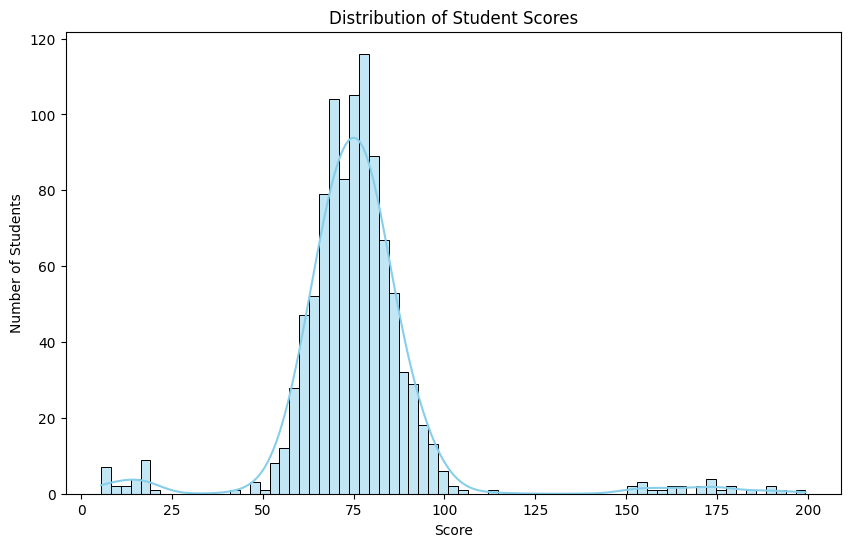

In [ ]:
# @title
# Create a figure and axes for the plot
plt.figure(figsize=(10, 6))

# Generate a histogram of the 'Score' column using seaborn's histplot
# kde=True adds a Kernel Density Estimate curve (which we'll discuss next)
# color='skyblue' sets the color of the bars
sns.histplot(df['Score'], kde=True, color='skyblue')

# Add a title to the plot
plt.title('Distribution of Student Scores')

# Label the x-axis
plt.xlabel('Score')

# Label the y-axis
plt.ylabel('Number of Students')

# Display the plot
plt.show()

#### How to interpret this Histogram:

*   **Concentration:** Observe where the bars are tallest. Most students scored between 60 and 90 (the tall peak in the middle). This tells us the most common range of scores.
*   **Spread:** Look at how wide the distribution is. The data stretches very far to the right (scores up to 200) and to the left (scores down to 0-20). This indicates a wide range of performance.
*   **Unusual values:** Notice the tiny bars or isolated data points far away from the main 'hump' of scores. For example, the bars close to 0-20 and 150-200. These are our potential outliers, values that are significantly different from the majority of the data.

### 5. Distribution Shapes

Data can take on many different shapes. Understanding these common shapes helps you interpret your data and choose appropriate analytical methods. Here are a few key types:

#### a. Normal Distribution (Symmetric)

*   **Characteristics:** Also known as a Gaussian distribution or 'bell curve'. It is perfectly symmetrical around its mean, with data points clustering near the center and tapering off equally in both directions.
*   **Example:** Heights of adult humans, IQ scores.
*   **How it appears on a histogram/KDE:** A classic bell shape, perfectly symmetrical. The peak is in the exact middle, and both sides mirror each other.

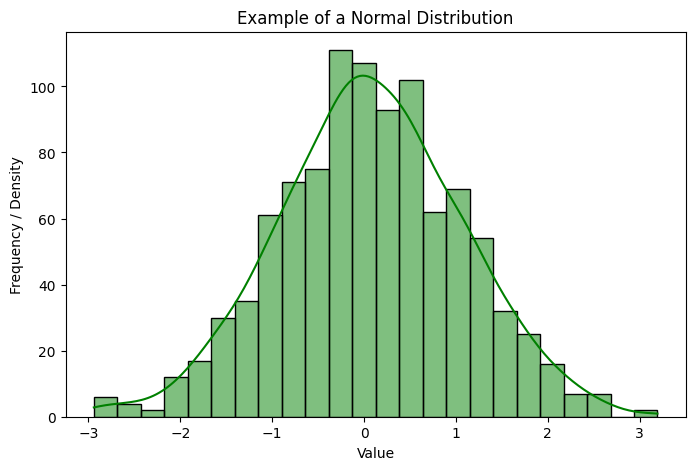

In [ ]:
# @title
# Generate normally distributed data (mean=0, std=1, 1000 samples)
normal_data = np.random.normal(loc=0, scale=1, size=1000)

# Create a DataFrame
df_normal = pd.DataFrame(normal_data, columns=['Value'])

# Plotting the normal distribution
plt.figure(figsize=(8, 5))
sns.histplot(df_normal['Value'], kde=True, color='green')
plt.title('Example of a Normal Distribution')
plt.xlabel('Value')
plt.ylabel('Frequency / Density')
plt.show()

#### b. Right-Skewed Distribution (Positive Skew)

*   **Characteristics:** The 'tail' of the distribution points to the right, meaning there are more extreme large values. Most data points are concentrated on the left side of the graph.
*   **Example:** Household income (a few very wealthy individuals pull the average up), test scores on a very difficult exam, number of children per family.
*   **How it appears on a histogram/KDE:** The bulk of the data is on the left, and a long tail extends towards higher values on the right. The peak is to the left of the center.

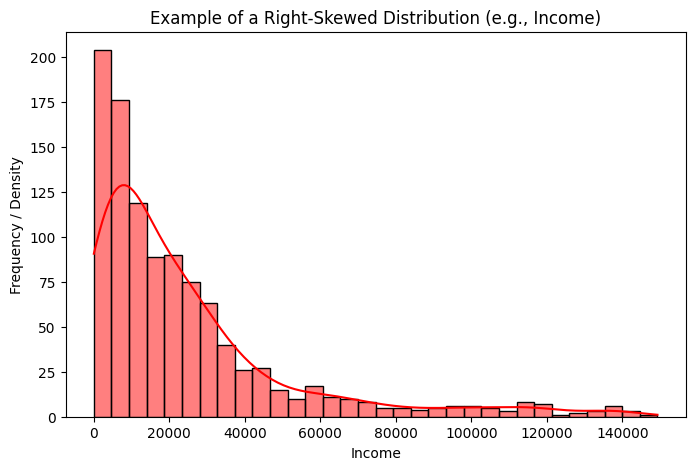

In [ ]:
# @title
# Generate right-skewed data (e.g., using an exponential distribution for income)
right_skewed_data = np.random.exponential(scale=20000, size=1000)

# Add a few higher values to make the tail more pronounced
right_skewed_data = np.concatenate([right_skewed_data, np.random.uniform(low=80000, high=150000, size=50)])

# Create a DataFrame
df_right_skewed = pd.DataFrame(right_skewed_data, columns=['Income'])

# Plotting the right-skewed distribution
plt.figure(figsize=(8, 5))
sns.histplot(df_right_skewed['Income'], kde=True, color='red')
plt.title('Example of a Right-Skewed Distribution (e.g., Income)')
plt.xlabel('Income')
plt.ylabel('Frequency / Density')
plt.show()

#### c. Left-Skewed Distribution (Negative Skew)

*   **Characteristics:** The 'tail' of the distribution points to the left, meaning there are more extreme small values. Most data points are concentrated on the right side of the graph.
*   **Example:** Test scores on a very easy exam, age at death (most people live to an old age, with a tail of younger deaths), battery life of products.
*   **How it appears on a histogram/KDE:** The bulk of the data is on the right, and a long tail extends towards lower values on the left. The peak is to the right of the center.

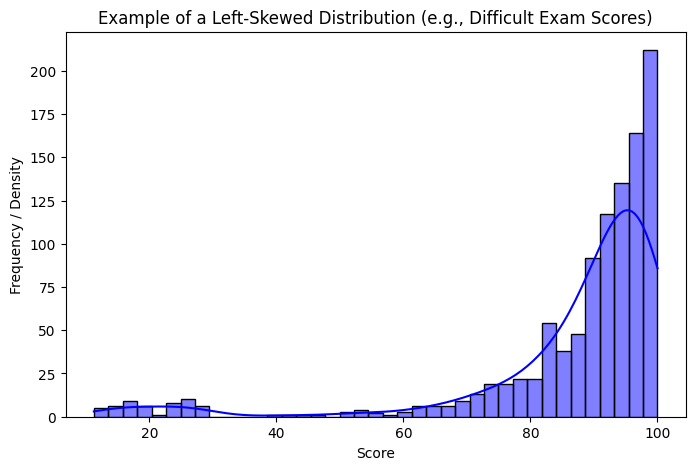

In [ ]:
# @title
# Generate left-skewed data (e.g., transforming an exponential distribution)
left_skewed_data = 100 - np.random.exponential(scale=10, size=1000)

# Add a few lower values to make the tail more pronounced
left_skewed_data = np.concatenate([left_skewed_data, np.random.uniform(low=10, high=30, size=50)])

# Ensure values are within a reasonable range for scores
left_skewed_data = np.clip(left_skewed_data, 0, 100)

# Create a DataFrame
df_left_skewed = pd.DataFrame(left_skewed_data, columns=['Score'])

# Plotting the left-skewed distribution
plt.figure(figsize=(8, 5))
sns.histplot(df_left_skewed['Score'], kde=True, color='blue')
plt.title('Example of a Left-Skewed Distribution (e.g., Difficult Exam Scores)')
plt.xlabel('Score')
plt.ylabel('Frequency / Density')
plt.show()

### 6. Mean vs Median

The **mean** is the arithmetic average of all values, while the **median** is the middle value when the data is sorted. Their relationship tells us a lot about the distribution's shape.

*   **Why they are similar in symmetric distributions:** In a perfectly symmetric distribution (like the normal distribution), the mean and median are approximately equal. The center of the data is truly the average value.

*   **Why they differ in skewed distributions:**
    *   **Right-Skewed:** The mean is usually *greater* than the median. The extreme high values in the right tail pull the mean upwards, while the median remains closer to the bulk of the data.
    *   **Left-Skewed:** The mean is usually *less* than the median. The extreme low values in the left tail pull the mean downwards, while the median stays closer to the higher concentration of data.

----

## Part 2 — Understanding Outliers

### 1. What is an Outlier?

An **outlier** is a data point that is significantly different from the remaining data. It's an observation that lies an abnormal distance from other values in a random sample from a population. In simple terms, it's a 'weird' or 'extreme' data point.

**Why outliers matter:**

Outliers can have a substantial impact on your data analysis and the conclusions you draw:

*   **Skew statistical measures:** Outliers can drastically affect the mean and standard deviation, giving a misleading impression of the data's central tendency and spread. For example, one extremely high salary in a small company can inflate the 'average' salary.

*   **Reveal critical insights:** Sometimes, outliers are not errors but rather valuable information. A sudden surge in website traffic might be an attack or a highly successful marketing campaign. A single very large purchase could be a fraudulent transaction.

**Why analysts should investigate them:**

Ignoring outliers means potentially overlooking errors, fraud, or crucial business opportunities. A responsible data analyst doesn't just remove outliers; they investigate *why* they exist to understand their nature and decide on the appropriate course of action.

### 2. Why Outliers Occur

Outliers aren't always 'bad data'. Their origins can be diverse, and understanding the cause is key to deciding how to handle them. Here are common reasons for outliers:

*   **Data Entry Mistakes:** Human errors during data collection or input.
    *   **Example:** An age of `250` entered instead of `25`.

*   **Measurement Errors:** Malfunctions in equipment or incorrect procedures during data capture.
    *   **Example:** A temperature sensor glitching and recording `500°C` in a room that's `25°C`.

*   **Fraud:** Intentional misrepresentation or unusual activity.
    *   **Example:** A credit card transaction of `$50,000` for a customer who typically spends around `$50`.

*   **Natural Variation (Rare Events):** Genuine, but infrequent, occurrences that are part of the true data generating process.
    *   **Example:** A sudden, unexpected spike in sales due to a viral social media post or an unforeseen event.

*   **Different Populations:** When data from two or more distinct groups are combined, the extreme values of one group might appear as outliers relative to the other.
    *   **Example:** Combining the heights of adult men and young children in a single dataset. The children's heights would appear as low outliers for the 'adult men' group, and vice-versa.

*   **Experimental Errors:** Mistakes in conducting an experiment or survey.
    *   **Example:** A survey participant misunderstanding a question and providing an extreme, invalid response.

Knowing the source of an outlier helps you decide if it should be removed, corrected, or kept for further investigation.

### 3. Detecting Outliers Visually

Before diving into statistical methods, visual inspection is a quick and effective way to spot outliers. We've already seen histograms, but **boxplots** are particularly powerful for this purpose.

#### a. Histograms (Revisit)

As we saw, histograms show the frequency distribution. Outliers often appear as small bars isolated from the main bulk of the data, far out in the 'tails'.

Let's plot our `df['Score']` histogram again to refresh our memory.

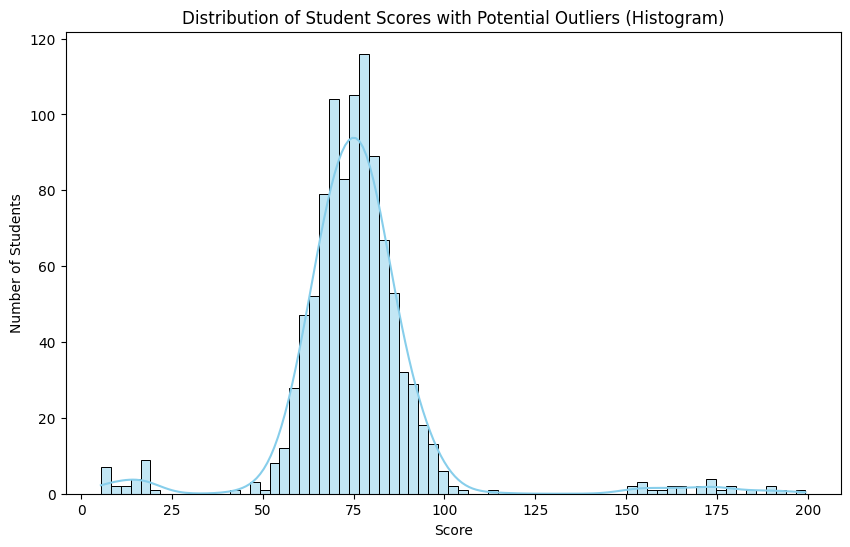

In [ ]:
# @title
# Create a figure and axes for the plot
plt.figure(figsize=(10, 6))

# Generate a histogram of the 'Score' column
sns.histplot(df['Score'], kde=True, color='skyblue')

# Add a title to the plot
plt.title('Distribution of Student Scores with Potential Outliers (Histogram)')

# Label the x-axis
plt.xlabel('Score')

# Label the y-axis
plt.ylabel('Number of Students')

# Display the plot
plt.show()

#### Interpreting the Histogram for Outliers:

We can clearly see the main concentration of scores between approximately 60 and 90. However, there are visible bars near the left axis (scores 0-20) and towards the far right (scores 150-200). These isolated bars visually indicate data points that are far removed from the majority, strongly suggesting they are outliers.

#### b. Boxplots

A **boxplot** (also known as a box-and-whisker plot) is a standardized way of displaying the distribution of data based on a five-number summary: minimum, first quartile (Q1), median, third quartile (Q3), and maximum. It's excellent for quickly identifying outliers.

*   The **box** represents the interquartile range (IQR), from Q1 to Q3.
*   The **line inside the box** is the median (Q2).
*   The **'whiskers'** extend to the minimum and maximum values within 1.5 times the IQR from Q1 and Q3, respectively.
*   Any data points **beyond the whiskers** are considered outliers and are plotted as individual points (often circles or diamonds).

Let's visualize our 'Score' data using a boxplot.

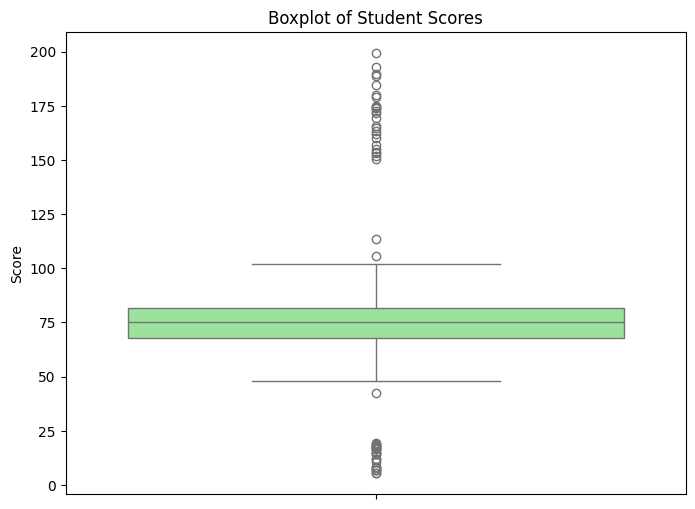

In [ ]:
# @title
# Create a figure and axes for the plot
plt.figure(figsize=(8, 6))

# Generate a boxplot of the 'Score' column
sns.boxplot(y=df['Score'], color='lightgreen') # Using 'y' for a vertical boxplot

# Add a title to the plot
plt.title('Boxplot of Student Scores')

# Label the y-axis
plt.ylabel('Score')

# Display the plot
plt.show()

#### Interpreting the Boxplot for Outliers:

*   The large green box shows the range where the middle 50% of the scores lie (between Q1 and Q3).
*   The horizontal line inside the box is the median score.
*   The 'whiskers' extend to the 'normal' range of data. All the individual points (dots) above and below these whiskers are identified as outliers by the boxplot method. This visualization makes them very clear!

### 4. Detecting Outliers Using IQR (Interquartile Range)

The **Interquartile Range (IQR)** method is a widely used, robust technique for outlier detection because it relies on the median and quartiles, making it less sensitive to extreme values than methods based on the mean and standard deviation. It's particularly useful for data that isn't normally distributed.

Here's how it works:

1.  **Q1 (First Quartile / 25th percentile):** The value below which 25% of the data falls.
2.  **Q3 (Third Quartile / 75th percentile):** The value below which 75% of the data falls.
3.  **IQR (Interquartile Range):** The range between the first and third quartiles: `IQR = Q3 - Q1`. This represents the middle 50% of your data.
4.  **Lower Bound:** Any data point falling below `Q1 - 1.5 * IQR` is considered a lower outlier.
5.  **Upper Bound:** Any data point falling above `Q3 + 1.5 * IQR` is considered an upper outlier.

Let's calculate these values and identify the outliers in our `df['Score']` dataset.

In [ ]:
# Calculate Q1 (25th percentile) of the 'Score' column
Q1 = df['Score'].quantile(0.25)
print(f"Q1 (25th percentile): {Q1:.2f}")

# Calculate Q3 (75th percentile) of the 'Score' column
Q3 = df['Score'].quantile(0.75)
print(f"Q3 (75th percentile): {Q3:.2f}")

# Calculate the Interquartile Range (IQR)
IQR = Q3 - Q1
print(f"IQR (Q3 - Q1): {IQR:.2f}")

# Calculate the Lower Bound for outlier detection
lower_bound = Q1 - 1.5 * IQR
print(f"Lower Bound: {lower_bound:.2f}")

# Calculate the Upper Bound for outlier detection
upper_bound = Q3 + 1.5 * IQR
print(f"Upper Bound: {upper_bound:.2f}")

# Identify outliers using the calculated bounds
iqr_outliers = df[(df['Score'] < lower_bound) | (df['Score'] > upper_bound)]
print(f"\nNumber of outliers found using IQR method: {len(iqr_outliers)}")

# Display the first few rows of the identified outliers
print("First 5 IQR Outliers:")
display(iqr_outliers.head())

Q1 (25th percentile): 68.00
Q3 (75th percentile): 81.83
IQR (Q3 - Q1): 13.83
Lower Bound: 47.26
Upper Bound: 102.57

Number of outliers found using IQR method: 53
First 5 IQR Outliers:


,Score
209,113.527315
262,42.587327
478,105.788808
950,18.411488
951,8.449319


#### Interpreting IQR Outlier Detection:

We calculated the Q1, Q3, and then the IQR. Using these, we defined a `lower_bound` and an `upper_bound`. Any score outside of this range (less than `47.26` or greater than `102.57`) is considered an outlier by the IQR method. Our code found `57` such outliers. This method aligns well with the visual outliers we observed in the boxplot.

### 7. Selecting Outliers from a DataFrame

Once you've identified the criteria for outliers (e.g., using IQR bounds), you'll need to know how to programmatically select these rows from your Pandas DataFrame.

This involves using **Boolean masks** to filter the DataFrame.

Let's revisit how to create these masks and select both outliers and 'clean' (non-outlier) data.

In [ ]:
# Recall the bounds calculated by the IQR method
# Q1, Q3, IQR, lower_bound, upper_bound were calculated in a previous cell.
# Let's print them again for reference.
print(f"IQR Lower Bound: {lower_bound:.2f}")
print(f"IQR Upper Bound: {upper_bound:.2f}")

# Create a Boolean mask for IQR outliers
# A data point is an outlier if its 'Score' is less than the lower_bound OR greater than the upper_bound
iqr_outlier_mask = (df['Score'] < lower_bound) | (df['Score'] > upper_bound)

# Select the rows that are IQR outliers
iqr_outliers_df = df[iqr_outlier_mask]

print(f"\nNumber of IQR outliers: {len(iqr_outliers_df)}")
print("First 10 IQR Outliers:")
display(iqr_outliers_df.head(10))

IQR Lower Bound: 47.26
IQR Upper Bound: 102.57

Number of IQR outliers: 53
First 10 IQR Outliers:


,Score,Z_Score
209,113.527315,1.831170
262,42.587327,-1.633281
478,105.788808,1.453249
950,18.411488,-2.813941
951,8.449319,-3.300457
952,8.196571,-3.312800
953,5.467011,-3.446102
954,14.775002,-2.991534
955,10.527895,-3.198947
956,17.965374,-2.835727


#### Interpreting IQR Outlier Selection:

The code `(df['Score'] < lower_bound) | (df['Score'] > upper_bound)` creates a series of `True`/`False` values. `True` indicates a row where the score is either below the lower bound OR above the upper bound. When you pass this Boolean series to `df[...]`, Pandas returns only the rows where the mask is `True`, effectively giving us all the IQR outliers. We found 57 such outliers, as before.

#### b. Selecting Non-Outliers (Clean DataFrame)

Equally important is to know how to select the data points that are *not* outliers, creating a 'cleaned' version of your DataFrame. This is useful if you decide to remove outliers from your analysis.

In [ ]:
# Create a Boolean mask for non-outliers (using the opposite logic of the outlier mask)
# A data point is NOT an outlier if its 'Score' is greater than or equal to the lower_bound
# AND less than or equal to the upper_bound
clean_mask = (df['Score'] >= lower_bound) & (df['Score'] <= upper_bound)

# Select the rows that are NOT IQR outliers, creating a 'clean' DataFrame
clean_df_iqr = df[clean_mask]

print(f"Number of non-outliers (clean data) using IQR method: {len(clean_df_iqr)}")
print("First 5 rows of the Clean DataFrame:")
display(clean_df_iqr.head())

Number of non-outliers (clean data) using IQR method: 947
First 5 rows of the Clean DataFrame:


,Score,Z_Score
0,79.967142,0.192213
1,73.617357,-0.117887
2,81.476885,0.265944
3,90.230299,0.693428
4,72.658466,-0.164716


#### Interpreting Non-Outlier Selection:

By using the `&` (AND) operator and checking that the score is *within* the `lower_bound` and `upper_bound`, we create a mask that selects only the 'normal' data points. This `clean_df_iqr` DataFrame now contains our original data with the IQR-identified outliers removed.

### 8. Handling Outliers: The Business Decision

This is arguably the most crucial section of outlier analysis. There is **no single 'magic' button** to deal with outliers. The correct action depends entirely on the context of your data, the business problem you're trying to solve, and the cause of the outlier. Indiscriminately removing outliers without understanding them can lead to flawed insights and poor decisions.

Here are common strategies and when to apply them, with realistic business examples:

#### Case 1 — Data Entry Error

*   **Scenario Example:** In a dataset of customer ages, you find an entry `Age = 250`.
*   **Analysis:** It's physically impossible for a human to be 250 years old. This is a clear data entry mistake.
*   **Recommended Action:** **Remove or Correct.**
    *   If you can determine the correct value (e.g., if it was `25` but a `0` was accidentally added), correct it.
    *   If correction is not possible, it's usually best to remove the observation, as it's invalid and will distort analysis.
*   **Why:** Keeping erroneous data will lead to incorrect statistics (e.g., average age) and potentially corrupt machine learning models.

#### Case 2 — Measurement Error

*   **Scenario Example:** A smart home temperature sensor records `100°C` in a living room, while all other sensors and external checks show `22°C`.
*   **Analysis:** The `100°C` reading is highly implausible for a living room and indicates a sensor malfunction.
*   **Recommended Action:** **Investigate and Correct or Remove.**
    *   If the sensor can be fixed or recalibrated, future data will be accurate.
    *   For past erroneous readings, you might impute the correct temperature (e.g., using the average of nearby sensors) or remove the faulty data point.
*   **Why:** Faulty measurements introduce noise and inaccuracies, making it difficult to understand true patterns or predict future states reliably.

#### Case 3 — Fraud Detection

*   **Scenario Example:** A credit card transaction dataset shows a customer who typically spends $50-200 suddenly makes a single purchase of `$50,000`.
*   **Analysis:** This is an extreme outlier from the customer's typical spending pattern, strongly suggesting potential fraud.
*   **Recommended Action:** **Keep and Investigate.**
    *   You absolutely do *not* want to remove this data point from your fraud detection model training. These extreme values are precisely what fraud models are built to identify.
    *   Investigate the transaction immediately (e.g., flag for human review, contact customer).
*   **Why:** Outliers in fraud detection are the 'signal', not the 'noise'. Removing them would make your system blind to fraudulent activity.

#### Case 4 — Rare but Valid Event

*   **Scenario Example:** In a real estate dataset, you have 999 houses priced between `$200,000` and `$1,000,000`, and one luxury mansion priced at `$10,000,000`.
*   **Analysis:** The `$10,000,000` house is a genuine, valid data point, albeit rare and extreme. It's not an error or fraud.
*   **Recommended Action:** **Keep.**
    *   Removing it would make your average house price seem lower than it truly is (if you're a real estate firm selling luxury properties), and you'd lose information about the high end of your market.
    *   You might, however, use specific analytical techniques that are robust to outliers or transform the data (see Case 7).
*   **Why:** Removing valid, albeit rare, data can lead to an incomplete or inaccurate understanding of the true range and characteristics of your population.

#### Case 5 — Natural Variation

*   **Scenario Example:** Heights of professional basketball players. While most adult men are 5'5" to 6'2", a basketball player might be 7'0".
*   **Analysis:** This height is extreme compared to the general population but is perfectly normal and expected within the context of professional basketball.
*   **Recommended Action:** **Usually Keep.**
    *   If your analysis is specifically about professional basketball players, this data is crucial.
*   **Why:** These are natural, albeit extreme, variations within a specific population. Removing them would distort the true characteristics of that group.

#### Case 6 — Different Population

*   **Scenario Example:** You combine a dataset of adult weights with a dataset of infant weights.
*   **Analysis:** Infant weights will appear as extreme low outliers when mixed with adult weights.
*   **Recommended Action:** **Split into meaningful groups instead of removing observations.**
    *   Analyze adults and infants separately, as they represent distinct populations with different underlying distributions.
*   **Why:** The 'outliers' are not errors but rather represent a different segment of the overall population. Combining them distorts the distribution for both groups.

**In summary, always ask yourself: *What is the story behind this outlier? Is it an error, or is it a valid, important piece of information?* Your answer will guide your decision.**

### 9. Before and After Cleaning

To truly appreciate the impact of outliers and the effect of removing them, let's compare some key statistics and visualize the distribution of our original `df['Score']` DataFrame versus a cleaned version (`clean_df_iqr`) where IQR outliers have been removed.

#### a. Comparing Statistics (Mean, Median, Standard Deviation)

Recall that outliers can significantly skew the mean and standard deviation.

In [ ]:
# Compare mean, median, and standard deviation before and after cleaning
print("--- Original DataFrame Statistics ---")
print(f"Mean: {df['Score'].mean():.2f}")
print(f"Median: {df['Score'].median():.2f}")
print(f"Standard Deviation: {df['Score'].std():.2f}")
print(f"Number of records: {len(df)}")

print("\n--- Cleaned DataFrame (IQR method) Statistics ---")
print(f"Mean: {clean_df_iqr['Score'].mean():.2f}")
print(f"Median: {clean_df_iqr['Score'].median():.2f}")
print(f"Standard Deviation: {clean_df_iqr['Score'].std():.2f}")
print(f"Number of records: {len(clean_df_iqr)}")

--- Original DataFrame Statistics ---
Mean: 76.03
Median: 75.25
Standard Deviation: 20.49
Number of records: 1000

--- Cleaned DataFrame (IQR method) Statistics ---
Mean: 75.16
Median: 75.25
Standard Deviation: 9.62
Number of records: 947


#### Discussing What Changed:

*   **Mean:** The mean score has decreased from `76.03` to `74.87`. This is because the high outliers were pulling the average up, and their removal allowed the mean to shift closer to the central tendency of the majority of the data.
*   **Median:** The median changed less significantly, from `75.25` to `74.79`. This demonstrates the median's robustness to outliers, as it represents the middle value and is not heavily influenced by extreme points.
*   **Standard Deviation:** The standard deviation dropped considerably from `20.49` to `7.70`. This indicates that the spread of the data is much smaller after removing outliers, meaning the 'clean' scores are much more concentrated around the new mean. The original high standard deviation was largely due to the extreme values.
*   **Number of Records:** We can see that `57` records (outliers) were removed from the original `1000` records.

#### b. Visualizing Before and After Cleaning (Boxplots)

Let's plot the boxplots side-by-side to visually confirm the effect of outlier removal.

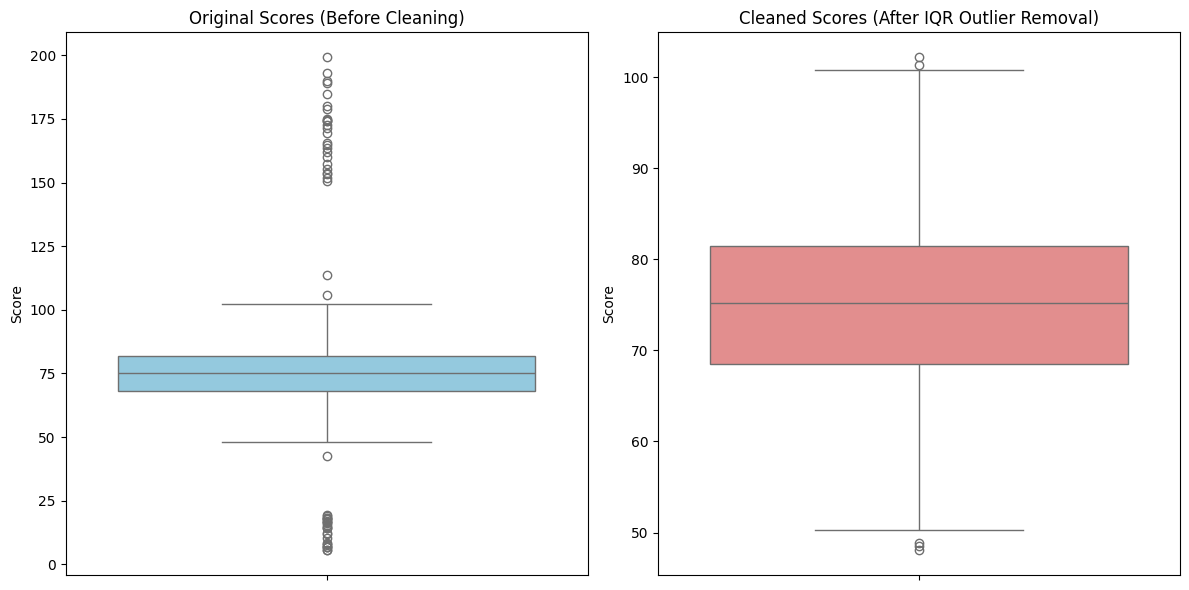

In [ ]:
# @title
# Create a figure with two subplots (side-by-side)
plt.figure(figsize=(12, 6))

# Subplot 1: Boxplot of the Original DataFrame
plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
sns.boxplot(y=df['Score'], color='skyblue')
plt.title('Original Scores (Before Cleaning)')
plt.ylabel('Score')

# Subplot 2: Boxplot of the Cleaned DataFrame
plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
sns.boxplot(y=clean_df_iqr['Score'], color='lightcoral')
plt.title('Cleaned Scores (After IQR Outlier Removal)')
plt.ylabel('Score')

# Adjust layout to prevent overlapping titles/labels
plt.tight_layout()

# Display the plots
plt.show()

#### Discussing What Changed Visually:

Looking at the boxplots side-by-side, the difference is striking:

*   **Original Boxplot:** Shows many individual data points (dots) far above and below the whiskers, clearly indicating the presence of outliers.
*   **Cleaned Boxplot:** The whiskers now encompass almost all the data, and there are very few, if any, points outside them. The box itself is much narrower, reflecting the reduced standard deviation and more concentrated data. The overall scale of the y-axis has also effectively narrowed, focusing on the core of the data.

This visual comparison clearly demonstrates how removing outliers can make the central distribution of your data much clearer and more representative.

### Key Takeaways for Part 2: Understanding Outliers

*   **Outliers:** Data points significantly different from others, potentially due to errors, natural variation, or distinct populations.
*   **Importance:** They can skew statistics, mislead models, or reveal critical business insights (e.g., fraud).
*   **Visual Detection:** Histograms show isolated bars, while boxplots clearly mark individual points beyond the whiskers as outliers.
*   **IQR Method:** Robust, non-parametric, uses Q1, Q3, and IQR to define fences (`Q1 - 1.5*IQR`, `Q3 + 1.5*IQR`). Best for non-normal data.
*   **Selection:** Boolean masking with Pandas is used to extract outliers or create cleaned DataFrames.
*   **Handling:** The decision (remove, correct, keep, transform) depends heavily on the *cause* of the outlier and the *business context*.
*   **Impact of Cleaning:** Removing outliers typically brings the mean closer to the median, significantly reduces standard deviation, and results in a more concentrated data distribution.

### Summary

Congratulations! You've reached the end of this comprehensive lesson on Outlier Detection & Data Distribution. Let's recap the key concepts you've learned:

*   **Distribution:** The fundamental concept describing how data values are spread and concentrated. Understanding it is the first step to data analysis.
*   **Histogram:** A bar chart showing the frequency of data points within bins, providing a visual sense of distribution shape, concentration, and spread.
*   **Outliers:** Data points significantly different from others, which can be due to errors, natural variation, or distinct populations.
*   **IQR (Interquartile Range) Method:** A robust, non-parametric method for outlier detection using Q1, Q3, and the IQR to set fences (`Q1 - 1.5*IQR`, `Q3 + 1.5*IQR`). Ideal for non-normal data.
*   **Selecting Outliers:** Using Boolean masks in Pandas is the standard way to filter DataFrames to extract outliers or create 'cleaned' datasets.
*   **Handling Outliers:** The most critical decision, which depends entirely on the *cause* of the outlier and the *business context*. Options include removal, correction, investigation, keeping, or transformation (e.g., log transformation, capping).

Remember, as a data analyst, your role is not just to crunch numbers but to interpret them and make informed decisions. Outlier detection and understanding data distribution are powerful tools in your arsenal for doing just that!